In [ ]:
!wget -O ../data/raw/CUAD_v1.zip https://zenodo.org/records/4595826/files/CUAD_v1.zip

In [36]:
import json
import pandas as pd

df = pd.read_json('../data/raw/CUAD_v1.json')
df.head()

,version,data
0,aok_v1.0,{'title': 'LIMEENERGYCO_09_09_1999-EX-10-DISTR...
1,aok_v1.0,"{'title': 'WHITESMOKE,INC_11_08_2011-EX-10.26-..."
2,aok_v1.0,{'title': 'LohaCompanyltd_20191209_F-1_EX-10.1...
3,aok_v1.0,{'title': 'CENTRACKINTERNATIONALINC_10_29_1999...
4,aok_v1.0,{'title': 'NELNETINC_04_08_2020-EX-1-JOINT FIL...


In [47]:
type(df)

pandas.DataFrame

In [64]:
rows = []
for contract in data['data']:
    for qa in contract['paragraphs'][0]['qas']:
        row = {}
        row['title'] = contract['title']
        row['clause_type'] = qa['id'].split('__')[1]
        row['question'] = qa['question']
        row['is_impossible'] = qa['is_impossible']
        row['answer_text'] = qa['answers'][0]['text'] if qa['answers'] else None
        rows.append(row)

In [65]:
df_flat = pd.DataFrame(rows)
df_flat.head()

,title,clause_type,question,is_impossible,answer_text
0,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Document Name,Highlight the parts (if any) of this contract ...,False,DISTRIBUTOR AGREEMENT
1,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Parties,Highlight the parts (if any) of this contract ...,False,Distributor
2,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Agreement Date,Highlight the parts (if any) of this contract ...,False,"7th day of September, 1999."
3,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Effective Date,Highlight the parts (if any) of this contract ...,False,The term of this Agreement shall be ten (10)...
4,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Expiration Date,Highlight the parts (if any) of this contract ...,False,The term of this Agreement shall be ten (10)...


In [66]:
df_flat.shape

(20910, 5)

In [67]:
df_flat['title'].nunique()

510

In [68]:
df_flat['is_impossible'].value_counts()

is_impossible
True     14208
False     6702
Name: count, dtype: int64

In [69]:
df_flat['clause_type'].value_counts()

clause_type
Document Name                         510
Parties                               510
Agreement Date                        510
Effective Date                        510
Expiration Date                       510
Renewal Term                          510
Notice Period To Terminate Renewal    510
Governing Law                         510
Most Favored Nation                   510
Non-Compete                           510
Exclusivity                           510
No-Solicit Of Customers               510
Competitive Restriction Exception     510
No-Solicit Of Employees               510
Non-Disparagement                     510
Termination For Convenience           510
Rofr/Rofo/Rofn                        510
Change Of Control                     510
Anti-Assignment                       510
Revenue/Profit Sharing                510
Price Restrictions                    510
Minimum Commitment                    510
Volume Restriction                    510
Ip Ownership Assignmen

In [72]:
df_flat.groupby('clause_type')['is_impossible'].mean().sort_values()

clause_type
Document Name                         0.000000
Parties                               0.001961
Agreement Date                        0.078431
Governing Law                         0.143137
Expiration Date                       0.190196
Effective Date                        0.235294
Anti-Assignment                       0.266667
Cap On Liability                      0.460784
License Grant                         0.500000
Audit Rights                          0.580392
Termination For Convenience           0.641176
Post-Termination Services             0.643137
Exclusivity                           0.647059
Renewal Term                          0.654902
Revenue/Profit Sharing                0.674510
Insurance                             0.674510
Minimum Commitment                    0.676471
Non-Transferable License              0.729412
Ip Ownership Assignment               0.756863
Change Of Control                     0.762745
Non-Compete                           0.766667
N

In [71]:
df_flat['answer_text'].dropna().apply(len).describe()

count    6702.000000
mean      254.439272
std       270.948060
min         1.000000
25%        42.000000
50%       194.000000
75%       351.000000
max      2820.000000
Name: answer_text, dtype: float64

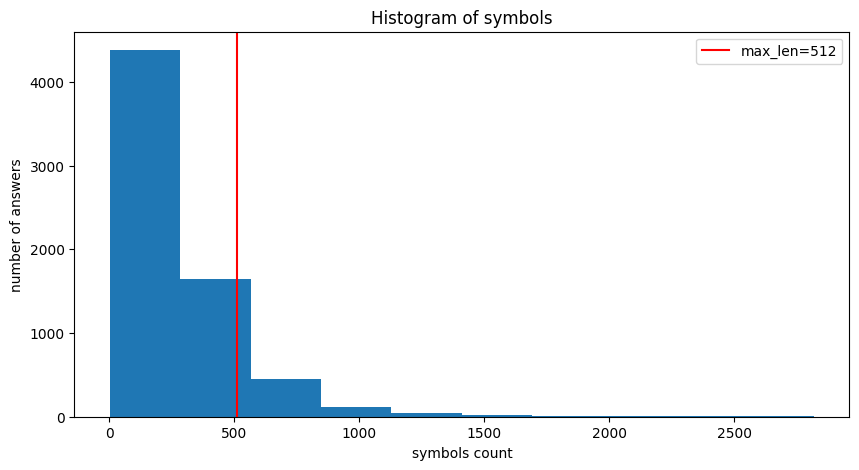

In [78]:
import matplotlib.pyplot as plt

plt.rcParams['text.usetex'] = False
plt.figure(figsize=(10, 5))
plt.hist(df_flat['answer_text'].dropna().apply(len))
plt.xlabel('symbols count')
plt.ylabel('number of answers')
plt.title('Histogram of symbols')
plt.axvline(512, color='r', label='max_len=512')
plt.legend()
plt.show()